In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.options.mode.copy_on_write = True

In [6]:
import os

print("CWD:", os.getcwd())
print("Aquí hay:", os.listdir())

CWD: c:\Users\Usuario\Desktop\bootcamp-data1\Ds-Online-Daniela-Aguirre\03_Data_Analysis\Sprint_08\Unidad_02_Visualizacion_Avanzada_Seaborn\03_Practica_Obligatoria\Visualizacion_titanic
Aquí hay: ['visualizacion_titanic.ipynb']


In [7]:
import os
os.chdir(r"C:\Users\Usuario\Desktop\bootcamp-data1\Ds-Online-Daniela-Aguirre\03_Data_Analysis\Sprint_08\Unidad_02_Visualizacion_Avanzada_Seaborn\03_Practica_Obligatoria")

print("CWD:", os.getcwd())
print("Aquí hay:", os.listdir())
print("Data:", os.listdir("data"))

CWD: C:\Users\Usuario\Desktop\bootcamp-data1\Ds-Online-Daniela-Aguirre\03_Data_Analysis\Sprint_08\Unidad_02_Visualizacion_Avanzada_Seaborn\03_Practica_Obligatoria
Aquí hay: ['18_Practica_Obligatoria_Visualizacion_Avanzada.ipynb', '18_Practica_Obligatoria_Visualizacion_Avanzada_SOL.ipynb', 'bootcampviztools.py', 'data', 'recursos', 'Visualizacion_titanic']
Data: ['california_cities.csv', 'titanic.csv']


In [8]:
df_titanic = pd.read_csv("data/titanic.csv")

Total pasajeros: 891
Supervivencia: 38.4% | Mortalidad: 61.6%


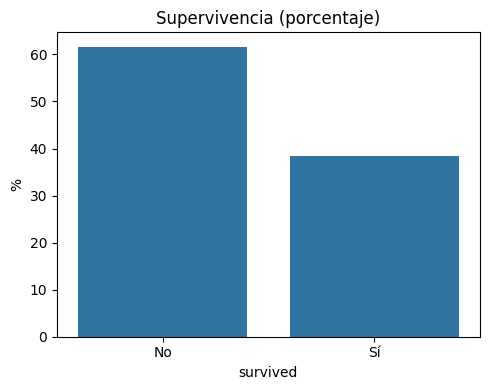

Supervivencia por sexo (%):
sex
female    74.2
male      18.9
Name: survived, dtype: float64


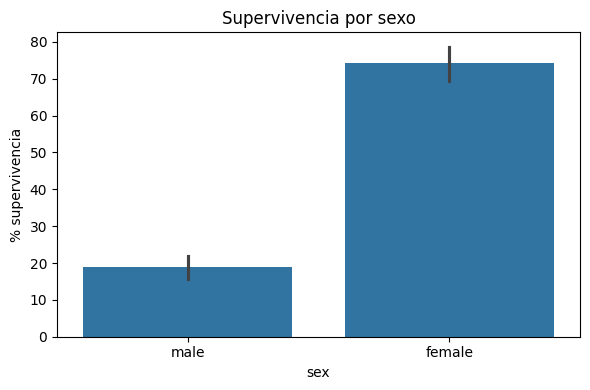

Supervivencia por clase (%):
pclass
1    63.0
2    47.3
3    24.2
Name: survived, dtype: float64


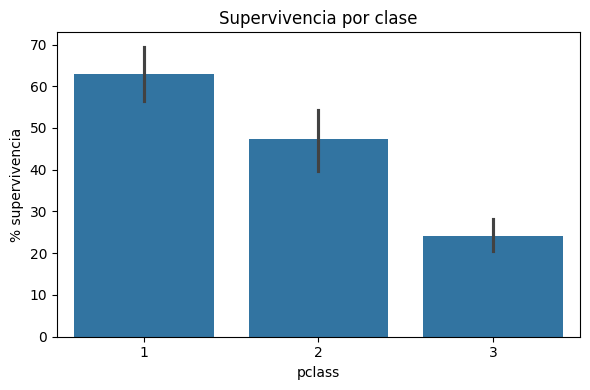

Supervivencia por grupo (%):
Group
women       77.5
children    59.0
male        17.4
Name: survived, dtype: float64


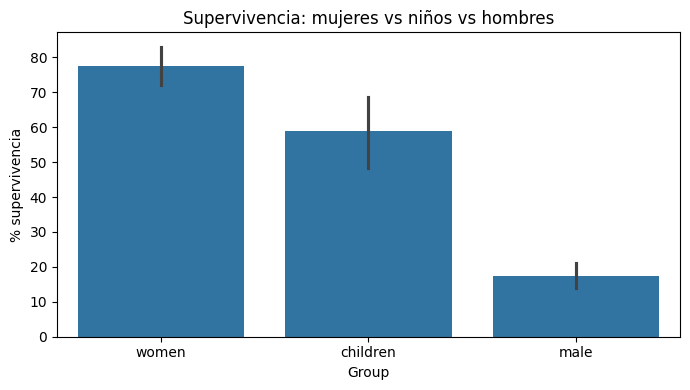

Supervivencia (%) por embark_town y pclass:
pclass           1     2     3
embark_town                   
Cherbourg     69.4  52.9  37.9
Queenstown    50.0  66.7  37.5
Southampton   58.3  46.3  19.0
unknown      100.0   NaN   NaN


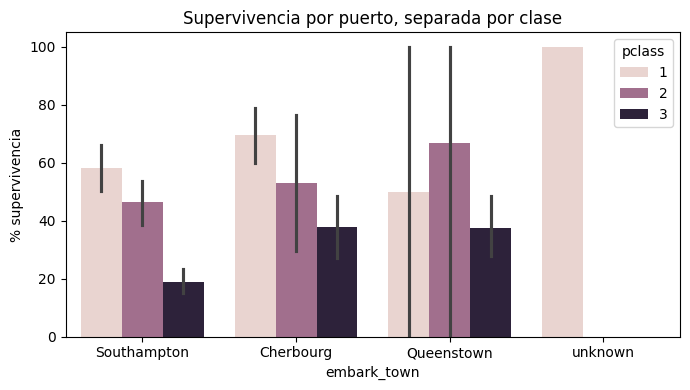

In [9]:
# Limpieza mínima
df_titanic  = df_titanic.dropna(subset=["survived", "sex", "pclass"])
df_titanic["embarked"] = df_titanic["embarked"].fillna("unknown")

#Slide 1 
total = len(df_titanic)
surv_rate = df_titanic["survived"].mean() * 100
mort_rate = 100 - surv_rate
print(f"Total pasajeros: {total}")
print(f"Supervivencia: {surv_rate:.1f}% | Mortalidad: {mort_rate:.1f}%")

# Slide 1: barra Survived (%)
plt.figure(figsize=(5,4))
sns.barplot(x=df_titanic["survived"].map({0:"No", 1:"Sí"}).value_counts(normalize=True).index,
            y=df_titanic["survived"].map({0:"No", 1:"Sí"}).value_counts(normalize=True).values*100)
plt.ylabel("%")
plt.title("Supervivencia (porcentaje)")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------------------------------------------------------------------------

# Slide 2 
sex_rates = df_titanic.groupby("sex")["survived"].mean() * 100
print("Supervivencia por sexo (%):")
print(sex_rates.round(1))

# Slide 2: supervivencia por sexo
plt.figure(figsize=(6,4))
sns.barplot(data=df_titanic, x="sex", y="survived", estimator=lambda x: x.mean()*100)
plt.ylabel("% supervivencia")
plt.title("Supervivencia por sexo")
plt.tight_layout()
plt.show()
 
# --------------------------------------------------------------------------------------------------------------------------------------------

# Slide 3
class_rates = df_titanic.groupby("pclass")["survived"].mean() * 100
print("Supervivencia por clase (%):")
print(class_rates.round(1))

# Slide 3: supervivencia por clase
plt.figure(figsize=(6,4))
sns.barplot(data=df_titanic, x="pclass", y="survived", estimator=lambda x: x.mean()*100)
plt.ylabel("% supervivencia")
plt.title("Supervivencia por clase")
plt.tight_layout()
plt.show()


#---------------------------------------------------------------------------------------------------------------------------------------------


# Slide 4: Men / Women / Children

df2 = df_titanic.dropna(subset=["age"]).copy()
df2["Group"] = "male"
df2.loc[df2["sex"]=="female", "Group"] = "women"
df2.loc[df2["age"] < 16, "Group"] = "children"

group_rates = df2.groupby("Group")["survived"].mean() * 100
print("Supervivencia por grupo (%):")
print(group_rates.reindex(["women", "children", "male"]).round(1))

plt.figure(figsize=(7,4))
order = ["women", "children", "male"]
sns.barplot(data=df2, x="Group", y="survived", order=order, estimator=lambda x: x.mean()*100)
plt.ylabel("% supervivencia")
plt.title("Supervivencia: mujeres vs niños vs hombres")
plt.tight_layout()
plt.show()


#-----------------------------------------------------------------------------------------------------------------------------------------------

# Slide 5: Embarked parece influir, pero separado por clase
df5 = df_titanic.copy()
df5["embark_town"] = df5["embark_town"].fillna("unknown")

# % supervivencia por puerto y clase
rates = df5.groupby(["embark_town", "pclass"])["survived"].mean().mul(100).round(1)
print("Supervivencia (%) por embark_town y pclass:")
print(rates.unstack())   # tabla: filas=embarked, columnas=pclass

# Gráfica
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=df5, x="embark_town", y="survived", hue="pclass",
    estimator=lambda x: x.mean()*100
)
plt.ylabel("% supervivencia")
plt.title("Supervivencia por puerto, separada por clase")
plt.tight_layout()
plt.show()